# Weed Detection Using YOLOv8 Instance Segmentation

This notebook trains a YOLOv8 segmentation model to detect:
- **Crop** (class 0): Bean plants
- **Weed** (class 1): Unwanted plants

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Install required packages
!pip install -q ultralytics opencv-python matplotlib numpy pillow
!pip install -q pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 6.5 MB/s eta 0:00:00


In [ ]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
from PIL import Image
from pycocotools import mask as coco_mask
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Now, let's update the `prepare_yolo_dataset` function to use this global `model_results_dir`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model_results_dir = Path('/content/drive/MyDrive/model_results')
os.makedirs(model_results_dir, exist_ok=True)
print(f"All model results will be saved to: {model_results_dir}")

All model results will be saved to: /content/drive/MyDrive/model_results


## Step 1: Convert COCO Segmentation to YOLO Format

YOLOv8 segmentation requires annotations in a specific format:
- Each annotation file contains: `class_id x1 y1 x2 y2 ... xn yn` (normalized polygon coordinates)

In [ ]:
def rle_to_polygon(rle_counts, rle_size):
    """
    Convert RLE segmentation to polygon coordinates.
    """
    # Decode RLE to binary mask
    rle = {'counts': rle_counts, 'size': rle_size}
    binary_mask = coco_mask.decode(rle)

    # Find contours
    contours, _ = cv2.findContours(
        binary_mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    # Get the largest contour
    contour = max(contours, key=cv2.contourArea)

    # Simplify polygon
    epsilon = 0.001 * cv2.arcLength(contour, True)
    polygon = cv2.approxPolyDP(contour, epsilon, True)

    # Flatten and normalize
    polygon = polygon.flatten().tolist()

    return polygon

In [ ]:
def convert_coco_to_yolo_seg(json_path, output_txt_path, class_id, img_width, img_height):
    """
    Convert a single COCO JSON annotation to YOLO segmentation format.

    Args:
        json_path: Path to COCO JSON file
        output_txt_path: Output path for YOLO format txt file
        class_id: Class ID (0 for crop, 1 for weed)
        img_width: Image width
        img_height: Image height
    """
    with open(json_path, 'r') as f:
        data = json.load(f)

    annotations = data.get('annotations', [])

    yolo_lines = []

    for ann in annotations:
        seg = ann.get('segmentation', {})

        # Handle RLE format
        if 'counts' in seg and 'size' in seg:
            polygon = rle_to_polygon(seg['counts'], seg['size'])

            if polygon is None or len(polygon) < 6:
                continue

            # Normalize coordinates
            normalized_coords = []
            for i in range(0, len(polygon), 2):
                x = polygon[i] / img_width
                y = polygon[i + 1] / img_height
                normalized_coords.extend([x, y])

            # Create YOLO format line: class_id x1 y1 x2 y2 ...
            yolo_line = f"{class_id} " + " ".join(map(str, normalized_coords))
            yolo_lines.append(yolo_line)

    # Write to file
    with open(output_txt_path, 'w') as f:
        f.write("\n".join(yolo_lines))

In [ ]:
def prepare_yolo_dataset():
    """
    Organize data into YOLO format structure:
    dataset/
        images/
            train/
        labels/
            train/
    """
    # Create directory structure
    global model_results_dir
    base_dir = model_results_dir / 'dataset'
    (base_dir / 'images' / 'train').mkdir(parents=True, exist_ok=True)
    (base_dir / 'labels' / 'train').mkdir(parents=True, exist_ok=True)

    # Process crop (beans) dataset - class_id = 0
    crop_dir = Path('/content/drive/MyDrive/traning images/crops/train')
    print("Processing crop (beans) images...")

    crop_jsons = list(crop_dir.glob('*.json'))
    for json_file in crop_jsons:
        # Get corresponding image - try both .jpeg and .jpg extensions
        img_path = None
        for ext in ['.jpeg', '.jpg']:
            potential_path = crop_dir / (json_file.stem + ext)
            if potential_path.exists():
                img_path = potential_path
                break

        if img_path and img_path.exists():
            # Read image to get dimensions
            img = Image.open(img_path)
            width, height = img.size

            # Copy image to dataset
            new_img_name = f"crop_{json_file.stem}.jpg"
            shutil.copy(img_path, base_dir / 'images' / 'train' / new_img_name)

            # Convert and save annotation
            txt_name = f"crop_{json_file.stem}.txt"
            convert_coco_to_yolo_seg(
                json_file,
                base_dir / 'labels' / 'train' / txt_name,
                class_id=0,  # crop class
                img_width=width,
                img_height=height
            )

    print(f"Processed {len(crop_jsons)} crop images")

    # Process weed dataset - class_id = 1
    weed_dir = Path('/content/drive/MyDrive/traning images/weed/train')
    print("\nProcessing weed images...")

    weed_jsons = list(weed_dir.glob('*.json'))
    for json_file in weed_jsons:
        # Get corresponding image - try both .jpeg and .jpg extensions
        img_path = None
        for ext in ['.jpeg', '.jpg']:
            potential_path = weed_dir / (json_file.stem + ext)
            if potential_path.exists():
                img_path = potential_path
                break

        if img_path and img_path.exists():
            # Read image to get dimensions
            img = Image.open(img_path)
            width, height = img.size

            # Copy image to dataset
            new_img_name = f"weed_{json_file.stem}.jpg"
            shutil.copy(img_path, base_dir / 'images' / 'train' / new_img_name)

            # Convert and save annotation
            txt_name = f"weed_{json_file.stem}.txt"
            convert_coco_to_yolo_seg(
                json_file,
                base_dir / 'labels' / 'train' / txt_name,
                class_id=1,  # weed class
                img_width=width,
                img_height=height
            )

    print(f"Processed {len(weed_jsons)} weed images")
    print(f"\nTotal images: {len(crop_jsons) + len(weed_jsons)}")
    print("\nDataset prepared successfully!")

In [ ]:
# Prepare the dataset
prepare_yolo_dataset()

Processing crop (beans) images...
Processed 374 crop images

Processing weed images...
Processed 15 weed images

Total images: 389

Dataset prepared successfully!


## Step 2: Create Dataset Configuration File

In [ ]:
# Create data.yaml for YOLOv8
data_yaml = f"""# Weed Detection Dataset
path: {model_results_dir / 'dataset'}  # absolute path to dataset root
train: images/train  # train images (relative to 'path')
val: images/train  # val images (using same as train for now)

# Classes
names:
  0: crop
  1: weed
"""

# Ensure data.yaml is created within the dataset directory inside model_results_dir
(model_results_dir / 'dataset').mkdir(parents=True, exist_ok=True)
with open(model_results_dir / 'dataset' / 'data.yaml', 'w') as f:
    f.write(data_yaml)

print("Created data.yaml configuration file at: " + str(model_results_dir / 'dataset' / 'data.yaml'))

Created data.yaml configuration file at: /content/drive/MyDrive/model_results/dataset/data.yaml


## Step 3: Train YOLOv8 Segmentation Model

In [ ]:
import requests

# Define the base model name and its target path within model_results_dir
base_model_name = 'yolov8n-seg.pt'
target_base_model_path = model_results_dir / base_model_name

# Check if the base model already exists in the target directory
if not target_base_model_path.exists():
    print(f"Downloading {base_model_name} to {target_base_model_path}...")
    # URL for downloading YOLOv8n-seg.pt (current version from Ultralytics assets)
    download_url = f"https://github.com/ultralytics/assets/releases/download/v8.4.0/{base_model_name}"

    try:
        response = requests.get(download_url, stream=True)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        with open(target_base_model_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded {base_model_name} successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading {base_model_name}: {e}")
        print("Attempting to load from default Ultralytics location (may re-download there).")
        # Fallback to default YOLO behavior if explicit download fails
        model = YOLO(base_model_name)
else:
    print(f"{base_model_name} already exists at {target_base_model_path}.")

# Load YOLOv8 segmentation model from the specified path
# If the explicit download failed, 'model' would have been set by the fallback.
# Otherwise, load from the target_base_model_path.
if 'model' not in locals(): # Check if fallback didn't already set 'model'
    model = YOLO(str(target_base_model_path))

print("Loaded YOLOv8-Seg model")

Downloaded yolov8n-seg.pt successfully.
Loaded YOLOv8-Seg model


In [14]:
import os

# Training parameters
EPOCHS = 100
IMG_SIZE = 640
BATCH_SIZE = 16
PATIENCE = 20  # Early stopping patience

# model_results_dir is already defined globally as a Path object.
# No need to redefine it here or call os.makedirs again.

# Train the model
results = model.train(
    data=str(model_results_dir / 'dataset' / 'data.yaml'), # Provide absolute path to data.yaml
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    name='weed_segmentation',
    patience=PATIENCE,
    save=True,
    device='0',  # Use GPU 0 (use 'cpu' for CPU training)
    plots=True,
    verbose=True,
    project=str(model_results_dir) # Save results to the specified directory
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/model_results/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/model_results/yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=weed_segmentation, nbs=64, nms=False, 

## Step 4: Validate the Model

In [20]:
# Validate the trained model
metrics = model.val()

print(f"\nValidation Results:")
print(f"mAP50: {metrics.seg.map50:.4f}")
print(f"mAP50-95: {metrics.seg.map:.4f}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 29.4±7.6 MB/s, size: 61.5 KB)
val: Scanning /content/drive/MyDrive/model_results/dataset/labels/train.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389 74.2Mit/s 0.0s
train: /content/drive/MyDrive/model_results/dataset/images/train/crop_image_099_jpeg.rf.4qUnDPDXkLmdJx68G472.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 2.8it/s 9.1s
                   all        389        397      0.996      0.996      0.995      0.992      0.995      0.995      0.995      0.952
                  crop        374        382      0.997      0.992      0.995      0.989      0.995       0.99      0.995      0.992
                  weed         15         15      0.994          1      0.995      0.995      0.995

In [24]:
validation_metrics_file = model_results_dir / 'validation_metrics.txt'
with open(validation_metrics_file, 'a') as f:
    f.write(f"mAP50: {metrics.seg.map50:.4f}\n")
    f.write(f"mAP50-95: {metrics.seg.map:.4f}\n")

print(f"Validation metrics saved to: {validation_metrics_file}")

Validation metrics saved to: /content/drive/MyDrive/model_results/validation_metrics.txt


## Step 5: Test on Sample Images


image 1/1 /content/drive/MyDrive/model_results/dataset/images/train/crop_image_594_jpeg.rf.H2mMN10GwYFSg2GIs9WL.jpg: 640x640 1 crop, 9.3ms
Speed: 3.5ms preprocess, 9.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


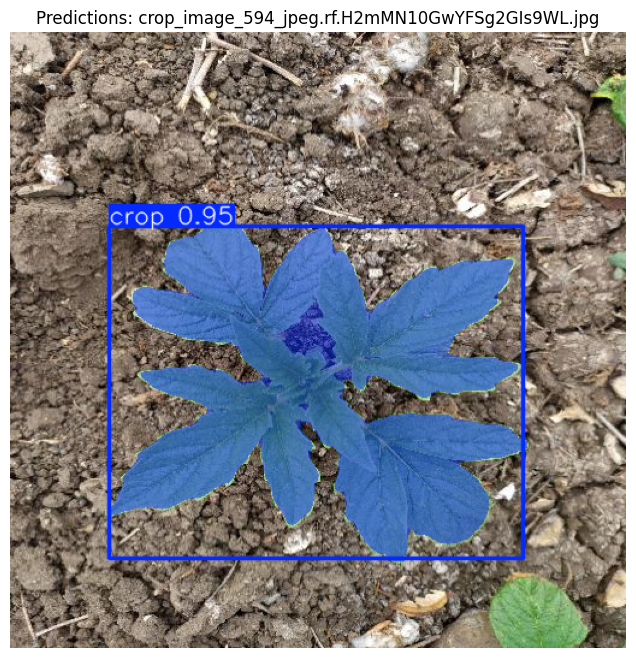


image 1/1 /content/drive/MyDrive/model_results/dataset/images/train/crop_image_177_jpeg.rf.ljhqwvu9EpVfGAvNhzNQ.jpg: 640x640 1 crop, 12.9ms
Speed: 3.4ms preprocess, 12.9ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)


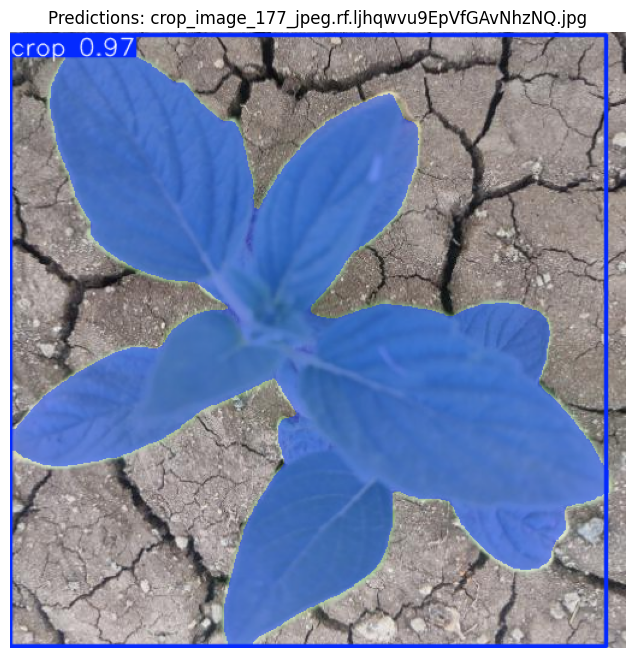


image 1/1 /content/drive/MyDrive/model_results/dataset/images/train/crop_image_475_jpeg.rf.a2IJb1tW2VZzYiOrPe7w.jpg: 640x640 1 crop, 13.7ms
Speed: 3.9ms preprocess, 13.7ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)


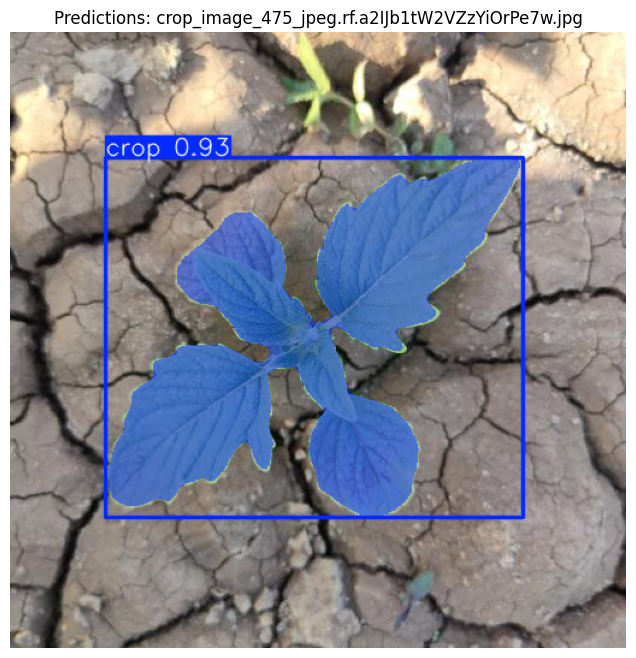


image 1/1 /content/drive/MyDrive/model_results/dataset/images/train/crop_image_038_jpeg.rf.5qGLpfuR8QsygWI20Uxg.jpg: 640x640 1 crop, 25.2ms
Speed: 4.1ms preprocess, 25.2ms inference, 4.9ms postprocess per image at shape (1, 3, 640, 640)


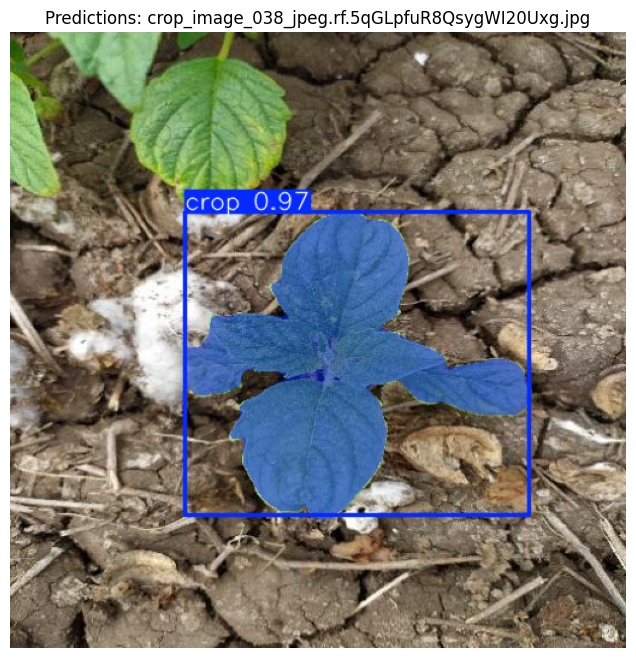


image 1/1 /content/drive/MyDrive/model_results/dataset/images/train/crop_image_568_jpeg.rf.B33ILud6UqCgwQqYo8rW.jpg: 640x640 1 crop, 18.5ms
Speed: 5.8ms preprocess, 18.5ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)


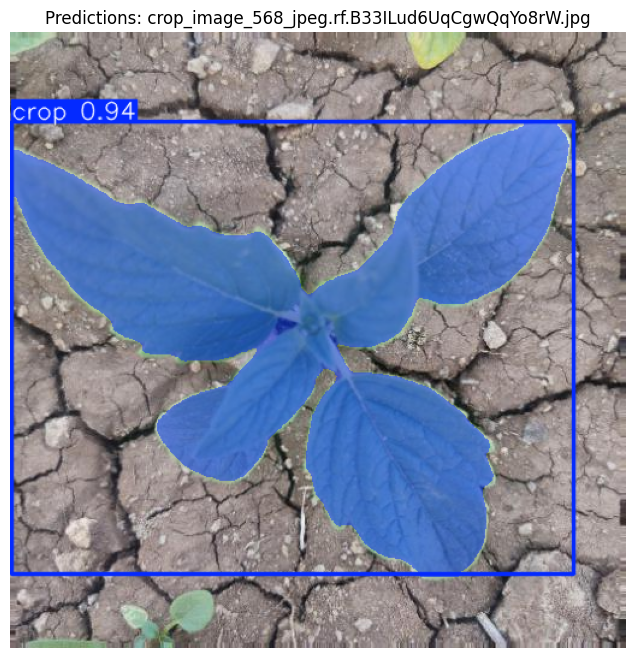

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

# Load the best trained model from the specified results directory
best_model_path = model_results_dir / 'weed_segmentation' / 'weights' / 'best.pt'
best_model = YOLO(str(best_model_path))

# Get some test images from the prepared dataset within the results directory
test_images_dir = model_results_dir / 'dataset' / 'images' / 'train'
test_images = list(test_images_dir.glob('*.jpg'))[:5]

for img_path in test_images:
    # Predict
    results = best_model.predict(source=str(img_path), conf=0.25, save=False, plots=False) # Set save=False to prevent default saving to runs/detect/predict

    # Visualize results
    for r in results:
        im_array = r.plot()  # plot a BGR numpy array of predictions
        im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image

        # Display
        plt.figure(figsize=(12, 8))
        plt.imshow(im)
        plt.axis('off')
        plt.title(f"Predictions: {img_path.name}")
        plt.show()

## Step 6: Export Model for Deployment

In [23]:
import os

# Export to different formats
# Options: 'onnx', 'torchscript', 'tflite', 'coreml', etc.

export_dir = model_results_dir / 'weed_segmentation' / 'weights'
export_dir.mkdir(parents=True, exist_ok=True)

# The name of the exported file will be 'best.onnx' within the project directory.
best_model.export(format='onnx', project=str(export_dir), name='best.onnx')
print(f"Model exported to ONNX format at: {export_dir / 'best.onnx'}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/model_results/weed_segmentation/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 38, 8400), (1, 32, 160, 160)) (6.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 641ms
Prepared 4 packages in 9.14s
Installed 4 packages in 463ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.0
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 10.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ON

## Class Definitions

- **Class 0 (crop)**: Bean plants - the desired plants to be protected
- **Class 1 (weed)**: Unwanted plants that should be removed